# Librerias que usamos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#división de datos para entrenamiento y validación
from sklearn.model_selection import train_test_split
#librerías principales de TensorFlow y Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
#define el modelo de entrada, aplicacion de filtros convolucionales (kernels),reduccion de dimension espacial
#pone matrices como vectores de 1D (para conectar la parte convolucional con las capas densas)
#Crea un "fully connected layer", Dropout desactiva aleatoriamente un % neuronas para evitar sobreajuste
#BatchNormalization normaliza la capa.
)

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# Carga de los datos y procesamientos

In [ ]:
train_data = pd.read_csv('Train.csv')
print("Dimensiones del conjunto de datos:", train_data.shape)
#separar las etiquetas (columna 0) de las características (resto de columnas)
X = train_data.iloc[:, 1:]  
y = train_data.iloc[:, 0]  #etiquetas: números del 0 al 9

#Un poco de limpieza de datos: convertir valores a numéricos y reemplazar posibles valores faltantes por 0
X=X.apply(pd.to_numeric, errors='coerce').fillna(0)
#normalizar los valores de píxeles al rango [0, 1]
X=X.values / 255.0
#reformatear cada muestra al tamaño de imagen 28x28 con un solo canal (escala de grises)
X=X.reshape(-1, 28, 28, 1)
print("Forma del conjunto de imágenes (X):", X.shape)

#convertir etiquetas a formato one-hot (vector binario de 10 posiciones)
y =to_categorical(y, num_classes=10)
print("Forma del conjunto de etiquetas (y):", y.shape)
#Dividir los datos en entrenamiento (80%) y validación (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_val:", X_val.shape)


Dimensiones del conjunto de datos: (42000, 785)
Forma del conjunto de imágenes (X): (42000, 28, 28, 1)
Forma del conjunto de etiquetas (y): (42000, 10)
Tamaño de X_train: (33600, 28, 28, 1)
Tamaño de X_val: (8400, 28, 28, 1)


# Data Augmentation

In [3]:
# se crean variaciones de las mismas imagenes (rotandolas, etc) para evitar el sobreajuste y mejorar el modelo
datagen = ImageDataGenerator(
    rotation_range=10,       #Rotacion aleatoria
    width_shift_range=0.1,   #Desplazamiento horizontal
    height_shift_range=0.1,  #Desplazamiento vertical
    zoom_range=0.1           #Zoom aleatorio
)
datagen.fit(X_train)

# Definicion del modelo (CNN)

In [ ]:
#Se utiliza un modelo secuencial de Keras con dos bloques convolucionales
#seguidos por capas densas totalmente conectadas para clasificación.

model = Sequential([
    #Capa de entrada (imágenes de 28x28 píxeles con 1 canal: escala de grises)
    Input(shape=(28, 28, 1)),
    
    #ambas capas convolucionales usan la función de activación ReLU,
    #y la capa de salida usa Softmax
    
    #Primer bloque convolucional
    Conv2D(32,(3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    #Segundo bloque convolucional
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    #Capa de aplanamiento y capas densas de clasificación
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(10, activation='softmax')#Salida -> dígitos del 0 al 9
])

#Compilación del modelo con Adaptive Moment Estimation y función de perdida adecuada
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',  #perdida para clasificación multiclase (one-hot)
    metrics=['accuracy']
)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 28, 28, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 422,026 (1.61 MB)

 Trainable params: 421,834 (1.61 MB)

 Non-trainable params: 192 (768.00 B)

# Configuracion de callbacks
### (para optimizar el entrenamiento)

In [5]:
#EarlyStopping -> detiene el entrenamiento si la perdida de validación deja de mejorar
#ReduceLROnPlateau -> reduce la tasa de aprendizaje si el progreso se estanca
#ModelCheckpoint -> guarda automaticamente el mejor modelo basado en la validación

callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(factor=0.5, patience=5, monitor='val_loss', verbose=1),
    ModelCheckpoint('Red_Neuronal.keras', save_best_only=True, monitor='val_loss', verbose=1)
]


# Entrenamiento del modelo

In [6]:
#El generador aplica transformaciones imagenes (las que justo se mencionaron al principio)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),#genera batches
    validation_data=(X_val, y_val),
    epochs=50, #número de epocas de entrenamiento
    callbacks=callbacks,
    verbose=1 #muestra información detallada del progreso por época
)

# El resultado se almacena en la variable 'history', que contiene métricas como pérdida y precisión tanto para entrenamiento como para validación en cada epoca


Epoch 1/50


C:\Users\Krisp\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


524/525 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7537 - loss: 0.7920
Epoch 1: val_loss improved from None to 0.22419, saving model to Red_Neuronal.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 25s 43ms/step - accuracy: 0.8601 - loss: 0.4494 - val_accuracy: 0.9239 - val_loss: 0.2242 - learning_rate: 0.0010
Epoch 2/50
524/525 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9426 - loss: 0.1955
Epoch 2: val_loss improved from 0.22419 to 0.10782, saving model to Red_Neuronal.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.9476 - loss: 0.1817 - val_accuracy: 0.9681 - val_loss: 0.1078 - learning_rate: 0.0010
Epoch 3/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9552 - loss: 0.1460
Epoch 3: val_loss improved from 0.10782 to 0.05448, saving model to Red_Neuronal.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.9567 - loss: 0.1439 - val_accuracy: 0.9826 - val_loss: 0.0545 - learning_rate: 0.0010
Epoch 4/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy

In [7]:
val_loss, val_acc = model.evaluate(X_val, y_val) #devuelve la perdida (loss) y la precision (accuracy
print(f"Precisión final en el conjunto de validación: {val_acc * 100:.2f}%")

263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9944 - loss: 0.0205
Precisión final en el conjunto de validación: 99.44%


# Validacion de las curvas de entrenamiento

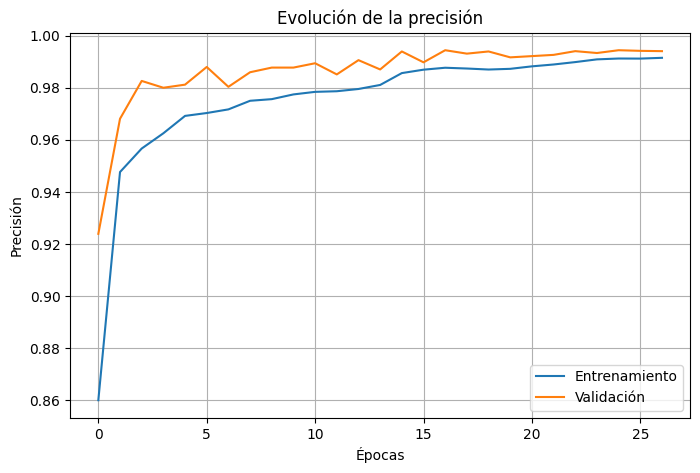

In [8]:
#Evolucion del Modelo
plt.figure(figsize=(8, 5))
#curva de precisión durante el entrenamiento
plt.plot(history.history['accuracy'], label='Entrenamiento')
#curva de precisión en los datos de validación
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Evolución de la precisión')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)
plt.show()

# Test del modelo

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


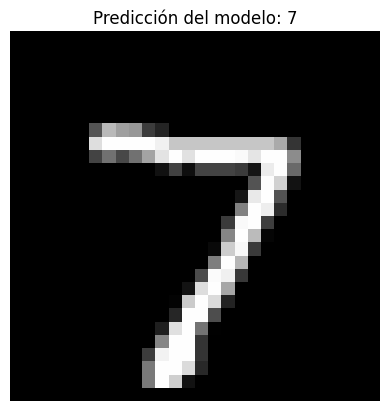

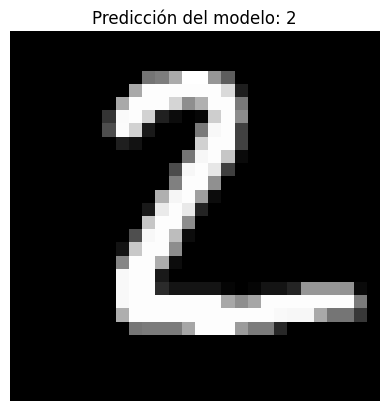

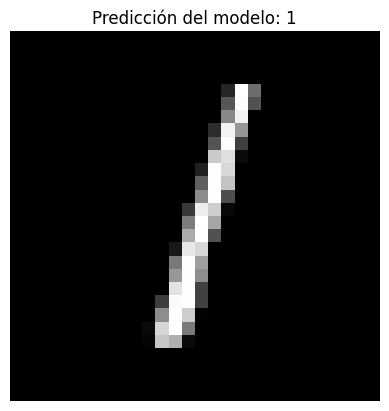

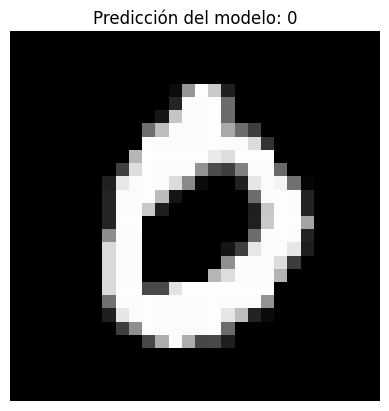

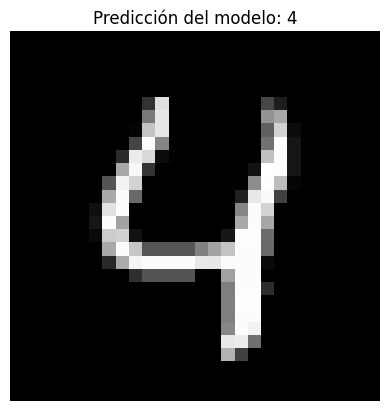

Modelo final guardado como: Red_Neuronal.keras


In [ ]:
from tensorflow.keras.datasets import mnist #se usa la libreria de keras para hacer un test al mismo modelo
(_, _), (X_test, _) = mnist.load_data() #Solo se cargan los test, lo demas no nos interesa
#Seleccionamos únicamente las primeras 10 imágenes
X_test = X_test[:10]

#Reformateamos las imágenes al tamaño y forma que espera la red osea 28x28x1
#y normalizamos los valores de píxeles al rango [0, 1]
X_test = X_test.reshape(-1, 28, 28, 1) / 255.0 

#Realizamos prediccion
predictions =model.predict(X_test) #contiene una probabilidad para cada clase (0–9) en cada imagen
#Usamos 'argmax' para obtener el índice (número) con mayor probabilidad
predicted_labels =np.argmax(predictions, axis=1)

#Mostramos las primeras 5 imagenes junto a la predicción del modelo
for i in range(5):
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Predicción del modelo: {predicted_labels[i]}")  #es el titulo con el numero predicho
    plt.axis('off')                                       
    plt.show()                                    
